In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mossbauer_analysis import utils as u
from mossbauer_analysis.mossbauer_theory import CobaltRhodium, CobaltFe, KFeCy, alphaFe, Mossbauer

In [3]:
def lorentzian(p,x):
    x0, Gamma, A, offset = p
    return 1-offset-A*(Gamma/2)**2 / ((x-x0)**2 + (Gamma/2)**2)

In [5]:

v = np.linspace(-10,10,1000)    


#SOURCES
sourceFe = CobaltFe ()
sourceFe.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
sourceFe.update_params()

sourceRh = CobaltRhodium()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 300e-9
absorber.abundance = 0.95
absorber.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorber.update_params()

#CALCULATIONS
moss_Fe_Fe = Mossbauer(sourceFe, absorber)
moss_Rh_Fe = Mossbauer(sourceRh, absorber)

t_Fe_Fe = moss_Fe_Fe.total_transmission_rate_attenuated(v)
t_Rh_Fe = moss_Rh_Fe.total_transmission_rate_attenuated(v)

In [6]:
sourceFe.Gamma
absorber.Gamma


0.09479166666666666



Mean squared residual: 4.765e-08

Covariance Matrix:

       p[0]  p[1]  p[2]  p[3]
 p[0]  1.00
 p[1]  0.02  1.00
 p[2] -0.01 -0.54  1.00
 p[3] -0.01 -0.56 -0.08  1.00

Final Parameters:

 p[0] = -4.30120e-08 +/- 4.1e-05 (96257.10%)
 p[1] = 2.14910e-01 +/- 1.4e-04 (0.07%)
 p[2] = 2.77197e-01 +/- 1.1e-04 (0.04%)
 p[3] = 1.63733e-02 +/- 3.1e-05 (0.19%)

0.21490988659053337 0.18958333333333333


(-3.0, 3.0)

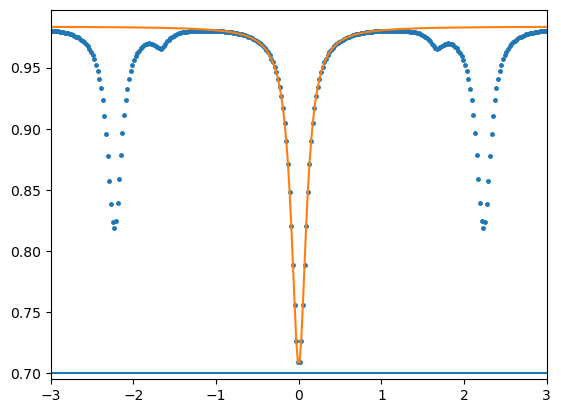

In [9]:
v = np.linspace(-10,10,1000)    

plt.plot(v, t_Fe_Fe ,'.',markersize = 5, label = 'Fe source')
#plt.plot(v, t_Rh_Fe,'.',markersize = 1, label = 'Rh source')

p0 = [0, 0.2, 0.3, 0.1]
idx1 = np.argmin(np.abs(v+1))
idx2 = np.argmin(np.abs(v-1))
p,dp = u.fit(lorentzian, v[idx1:idx2], t_Fe_Fe[idx1:idx2],p0, fullout=True)
plt.plot(v, lorentzian(p,v), label = 'Lorentian')


Gamma_tot = p[1]
Contrast = p[2]
print(p[1], sourceFe.Gamma+absorber.Gamma) 


plt.axhline(0.7)
#plt.ylim(0,1)
plt.xlim(-3,3)

(-1.0, 1.0)

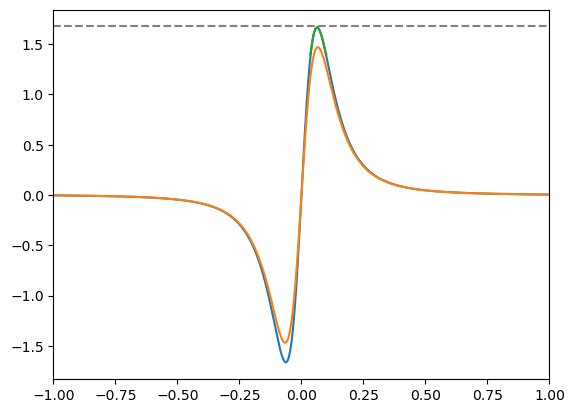

In [7]:
v = np.linspace(-10,10,1000)    
v = np.linspace(-3,3,1000)    
transmission = moss_Fe_Fe.total_transmission_rate_attenuated(v)
derivative = np.gradient(transmission, v[1]-v[0])
plt.plot(v, derivative, label='Derivative')
plt.plot(v, derivative*np.sqrt(transmission), label='Derivative*root(n)')

v = np.linspace(0.035,0.1,20)
transmission = moss_Fe_Fe.total_transmission_rate_attenuated(v)
derivative = np.gradient(transmission, v[1]-v[0])

plt.axhline(3*np.sqrt(3)*Contrast/(4*Gamma_tot), color='gray', linestyle='--')
plt.plot(v, derivative, label='Derivative')

plt.xlim(-1,1)

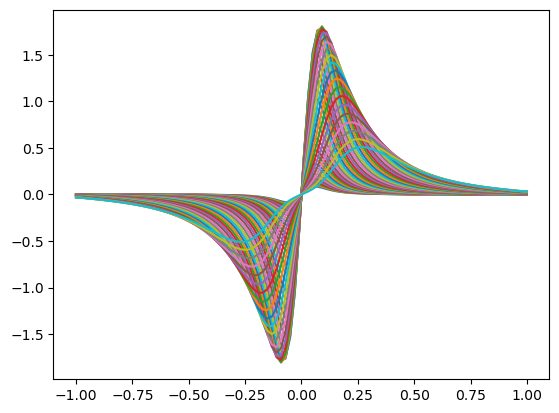

In [11]:
# Optimization of absorber thickneess. 

derivative_max = []
sensitivity_max = []

v = np.linspace(-1,1,100)
thicknesses = np.logspace(-8, -5, 50)
for t in thicknesses:
    absorber.thickness_m = t
    absorber.update_params()
    moss_Fe_Fe = Mossbauer(sourceFe, absorber)    
    transmission = moss_Fe_Fe.total_transmission_rate_attenuated(v)
    derivative = np.gradient(transmission, v[1]-v[0])
    #plt.plot(v, transmission)
    #plt.plot(v, derivative)
    plt.plot(v, derivative*np.sqrt(transmission))
    derivative_max.append(np.max(derivative))
    sensitivity_max.append(np.max(derivative*np.sqrt(transmission)))



Optimal thickness: 791 nm


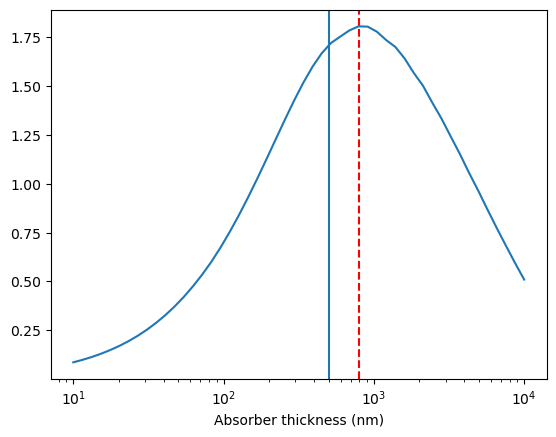

In [14]:
#plt.semilogx(thicknesses*1e9, derivative_max)
plt.semilogx(thicknesses*1e9, sensitivity_max)
t_optimal = thicknesses[np.argmax(sensitivity_max)]
print(f'Optimal thickness: {t_optimal*1e9:.0f} nm')
plt.axvline(t_optimal*1e9, color='red', linestyle='--', label=f'Optimal thickness: {t_optimal*1e9:.0f} nm')
plt.xlabel('Absorber thickness (nm)')
plt.axvline(500)